In [1]:
# Imports
import sys
sys.path.insert(1, '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/')
import importlib
import numpy as np
import awkward as ak
import pandas as pd
# from particle import Particle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.mplot3d import Axes3D
from python.analysis import BeamParticleSelection, Master, SelectionTools, PFOSelection
from python.analysis import SelectionEvaluation as seval
from python.analysis import Tags, Plots
from python.pdhd_MC import beam_selection
importlib.reload(Master)
importlib.reload(BeamParticleSelection)
importlib.reload(SelectionTools)
importlib.reload(Tags)
importlib.reload(beam_selection)

2026-07-02 12:39:02.331245: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<module 'python.pdhd_MC.beam_selection' from '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/python/pdhd_MC/beam_selection.py'>

In [2]:
filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v7__gen_g4_IonScintPDExt_PDInt.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [3]:
## Beam Instrumentation Selection

true_beam_mask = beam_selection.BeamTriggerSelection(events, return_property=True)
mask = true_beam_mask[0]
bi_evts = events.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [6]:
def tpc_entrance_mask(evts):
    traj_z = evts.trueParticles.beam_traj_pos.z
    traj_z = traj_z[traj_z >= 0]
    mask = evts.trueParticles.beam_traj_pos.z == ak.firsts(traj_z)
    return mask

def ke_to_p(evts):
    ff_mask = beam_selection.tpc_entrance_mask(evts)
    true_KE_ff = ak.fill_none(ak.firsts(evts.trueParticles.beam_traj_KE[ff_mask]), 0)
    pdg = evts.trueParticles.pdg[:, 0]
    mass = ak.where(pdg == 211, 139.57, ak.where(pdg == -13, 105.66, 0))
    return ((true_KE_ff + mass)**2 - mass**2)**0.5

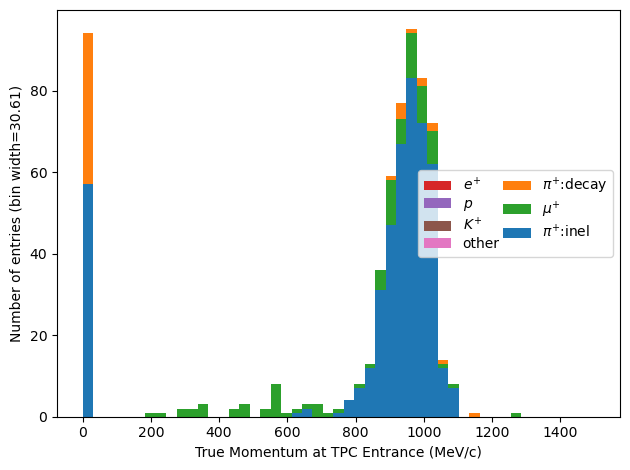

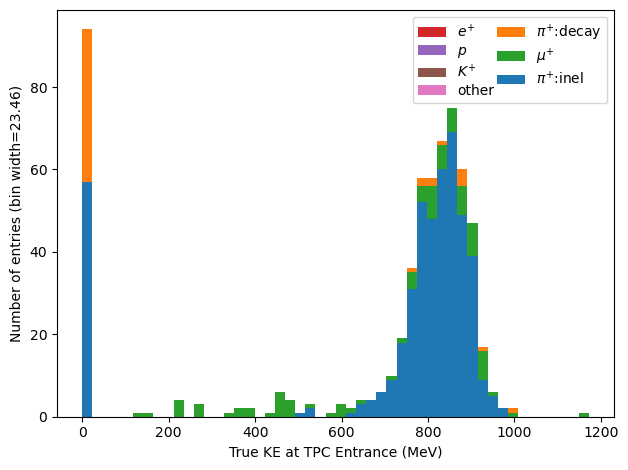

In [8]:
ff_mask = beam_selection.tpc_entrance_mask(selected_evts)
tags = Tags.GenerateTrueBeamParticleTags(selected_evts)
true_KE_ff = ak.fill_none(ak.firsts(selected_evts.trueParticles.beam_traj_KE[ff_mask]), 0)
true_P_ff = ke_to_p(selected_evts)
bins = np.linspace(0, 1500, 50)
Plots.PlotTagged(true_P_ff, tags, bins=bins, y_scale='linear', x_label="True Momentum at TPC Entrance (MeV/c)")
plt.show()

Plots.PlotTagged(true_KE_ff, tags, bins=50, y_scale='linear', x_label="True KE at TPC Entrance (MeV)")
plt.show()

In [3]:
import uproot

tree = uproot.open(filename)

In [9]:
tree['pduneana/beamana;1'].keys()

['run',
 'subrun',
 'event',
 'MC',
 'reco_reconstructable_beam_event',
 'reco_beam_type',
 'reco_beam_startX',
 'reco_beam_startY',
 'reco_beam_startZ',
 'reco_beam_endX',
 'reco_beam_endY',
 'reco_beam_endZ',
 'true_beam_len',
 'reco_beam_len',
 'reco_beam_alt_len',
 'for_truncation_method',
 'reco_beam_calo_startX',
 'reco_beam_calo_startY',
 'reco_beam_calo_startZ',
 'reco_beam_calo_endX',
 'reco_beam_calo_endY',
 'reco_beam_calo_endZ',
 'reco_beam_calo_startDirX',
 'reco_beam_calo_startDirY',
 'reco_beam_calo_startDirZ',
 'reco_beam_calo_endDirX',
 'reco_beam_calo_endDirY',
 'reco_beam_calo_endDirZ',
 'reco_beam_trackDirX',
 'reco_beam_trackDirY',
 'reco_beam_trackDirZ',
 'reco_beam_trackEndDirX',
 'reco_beam_trackEndDirY',
 'reco_beam_trackEndDirZ',
 'reco_beam_vertex_nHits',
 'reco_beam_vertex_michel_score',
 'reco_beam_vertex_michel_score_weight_by_charge',
 'reco_beam_trackID',
 'n_beam_slices',
 'n_beam_particles',
 'beam_track_IDs',
 'beam_particle_scores',
 'reco_beam_dQdX_

In [10]:
import uproot

#filename = "/storage/1/st15719/dune/H4_v34b_1GeV_-27.7_10M_1.root"
filename = "/storage/2/gj23442/H4_v34b_1GeV_-27.7_006685_412474_1_20250613T180853.root"
tree = uproot.open(filename)

generator_info = tree['NTuples;1']['GoodParticle;1']
generator_prop = generator_info.keys()

In [15]:
pdgid_prop_list = list(filter(lambda x: x and x[-5:]=='PDGid', generator_prop))
pdgids, counts = [], []
for prop in pdgid_prop_list:
    data = np.array(generator_info[prop].array())
    ids, count = np.unique(data, return_counts=True)
    pdgids.append(ids)
    counts.append(count)

print(counts)
pdgids = ak.Array(pdgids)
counts = ak.Array(counts)

[array([  4, 750,  29, 288,   1, 252]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 753, 293,   1, 255,   1]), array([ 21, 730, 106, 232, 234,   1])]


In [14]:
for i in range(len(pdgids)):
    print(f"PDG IDs for {pdgid_prop_list[i]}: {pdgids[i]}")
    print(f"Counts for {pdgid_prop_list[i]}: {counts[i]}")

PDG IDs for AfterTarget_PDGid: [-13, -11, 0, 211, 321, 2.21e+03]
Counts for AfterTarget_PDGid: [4, 750, 29, 288, 1, 252]
PDG IDs for TOF1_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for TOF1_PDGid: [21, 753, 293, 1, 255, 1]
PDG IDs for COLL1_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for COLL1_PDGid: [21, 753, 293, 1, 255, 1]
PDG IDs for BPROF1_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for BPROF1_PDGid: [21, 753, 293, 1, 255, 1]
PDG IDs for BPROF2_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for BPROF2_PDGid: [21, 753, 293, 1, 255, 1]
PDG IDs for BPROF3_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for BPROF3_PDGid: [21, 753, 293, 1, 255, 1]
PDG IDs for TRIG1_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for TRIG1_PDGid: [21, 753, 293, 1, 255, 1]
PDG IDs for BPROFEXT_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for BPROFEXT_PDGid: [21, 753, 293, 1, 255, 1]
PDG IDs for BPROF4_PDGid: [-13, -11, 211, 321, 2.21e+03, 1e+09]
Counts for BPR